In [6]:
#1.导入数据
from sklearn.datasets import fetch_olivetti_faces
import os
faces = fetch_olivetti_faces(data_home=r"D:\your_envs")
X = faces.data
y = faces.target

print(f"数据形状: {X.shape}")  # (400, 4096)
print(f"样本数: {X.shape[0]}, 特征维度: {X.shape[1]}")
print(f"类别数: {len(np.unique(y))}")

数据形状: (400, 4096)
样本数: 400, 特征维度: 4096
类别数: 40


In [8]:
import matplotlib.pyplot as plt
import matplotlib

# 在绘图前添加以下代码
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False 

降维后特征数: 123


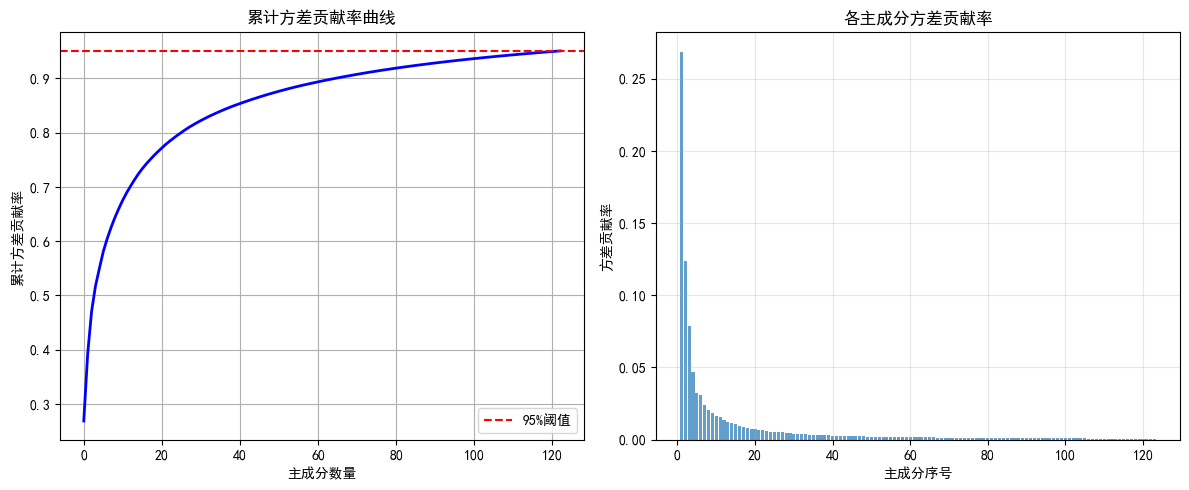


显示前10个主成分（特征脸）


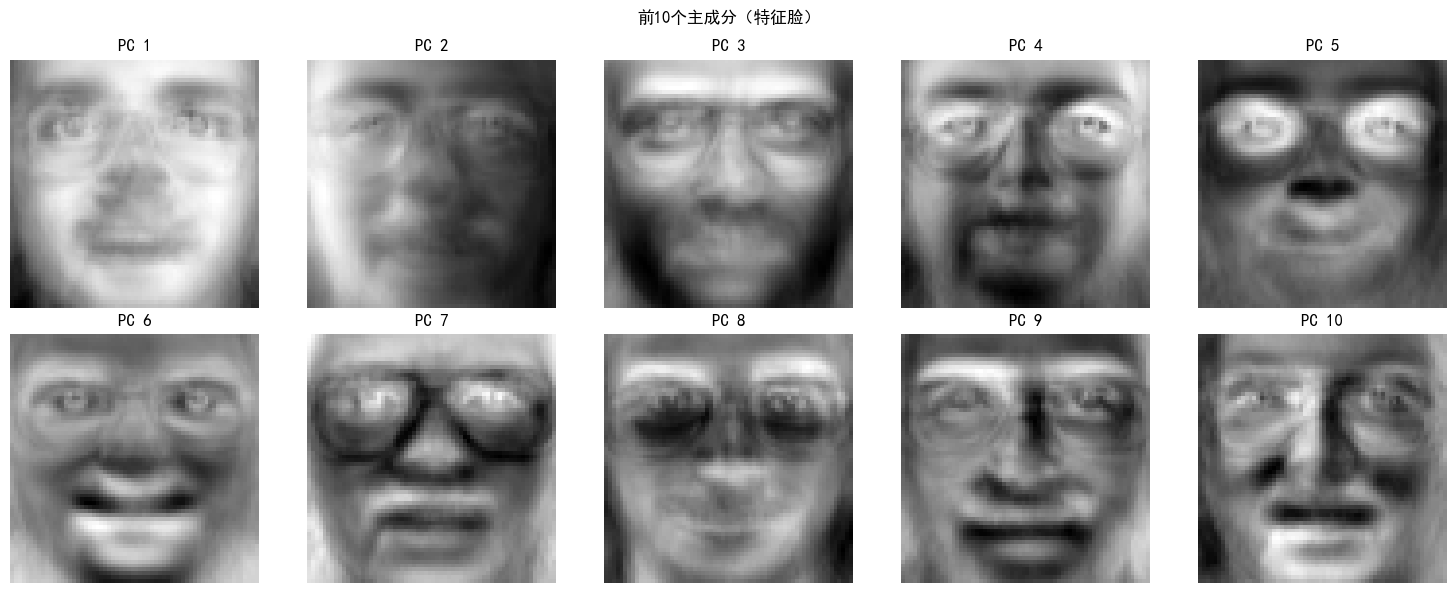


PCA重构效果示例


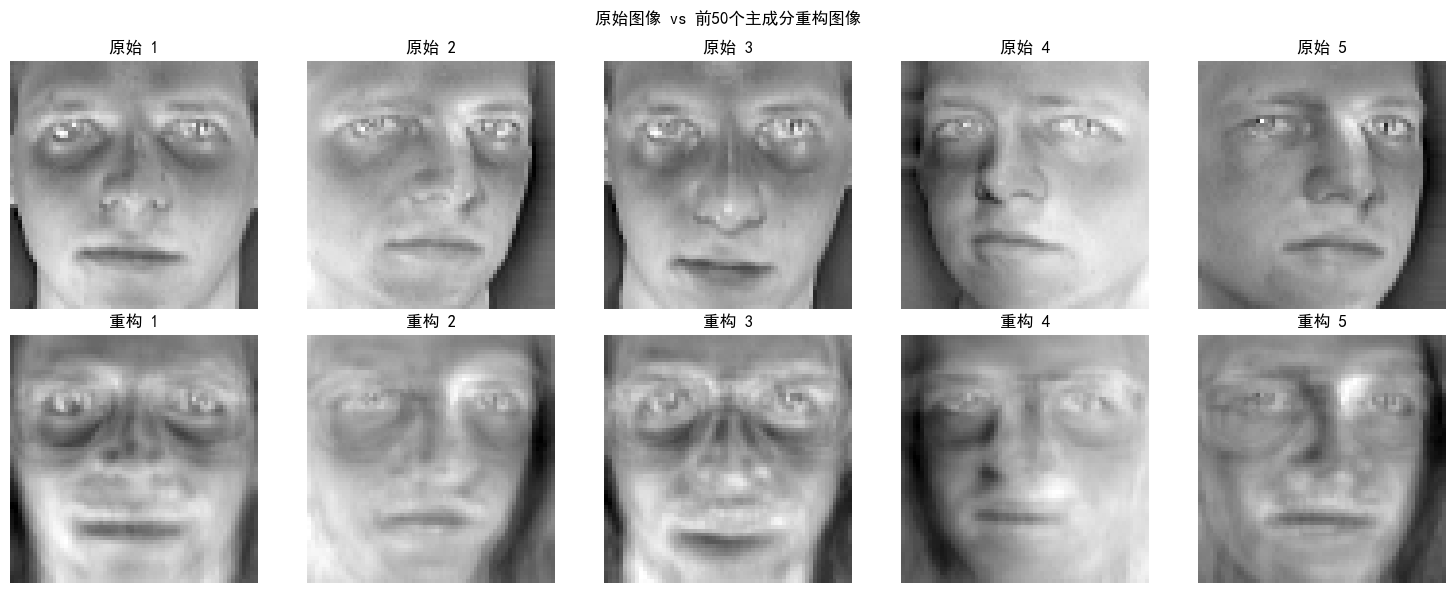


不同主成分数量的重构效果


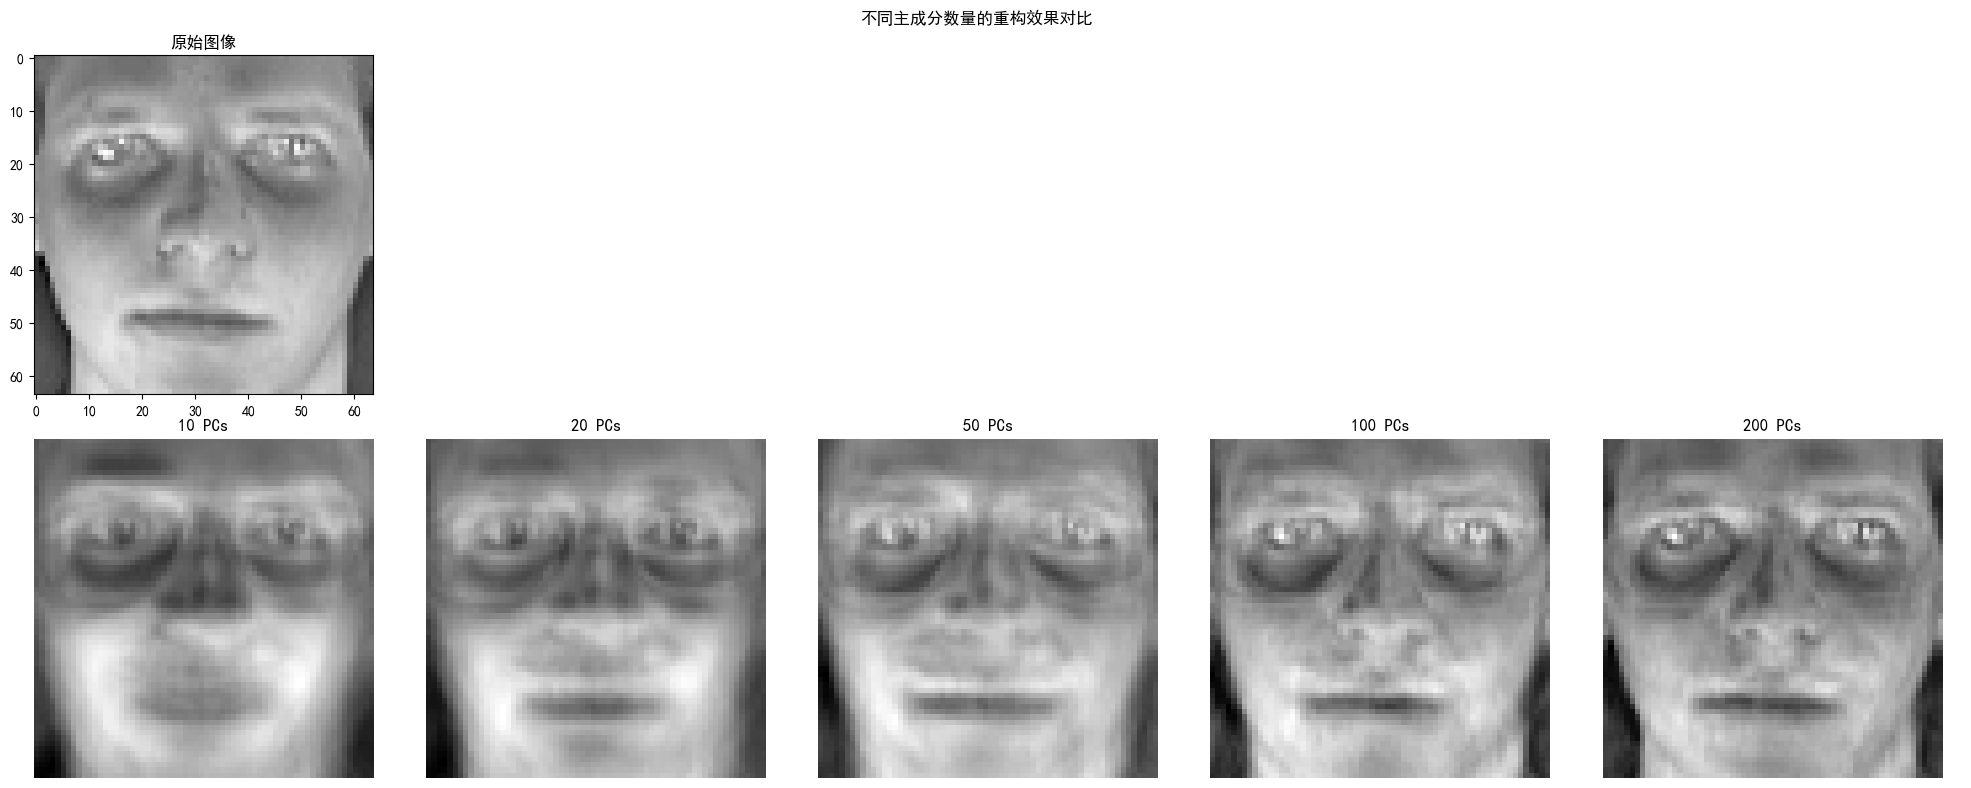

PCA分析统计结果:
原始特征维度: 4096
保留95%方差所需的主成分数: 123
降维比例: 97.00%
前10个主成分累计方差贡献率: 66.06%
前50个主成分累计方差贡献率: 87.43%
前100个主成分累计方差贡献率: 93.56%


In [13]:
##主成分
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# 2. 数据预处理（标准化）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA分析保留95%的方差
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"降维后特征数: {X_pca.shape[1]}")

# 4. 计算累计方差贡献率
cumsum = np.cumsum(pca.explained_variance_ratio_)

# 5. 可视化：累计方差贡献率
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cumsum, 'b-', linewidth=2)
plt.xlabel('主成分数量')
plt.ylabel('累计方差贡献率')
plt.title('累计方差贡献率曲线')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95%阈值')
plt.legend()

# 6. 可视化：每个主成分的方差贡献率
plt.subplot(1, 2, 2)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_, alpha=0.7)
plt.xlabel('主成分序号')
plt.ylabel('方差贡献率')
plt.title('各主成分方差贡献率')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7. 显示前几个主成分（特征脸）
print("\n显示前10个主成分（特征脸）")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.ravel()):
    if i < 10:
        # 重塑为64x64的图像
        eigenface = pca.components_[i].reshape(64, 64)
        ax.imshow(eigenface, cmap='gray')
        ax.set_title(f'PC {i+1}')
        ax.axis('off')
plt.suptitle('前10个主成分（特征脸）')
plt.tight_layout()
plt.show()

# 8. 选择前50个主成分进行重构示例
print("\nPCA重构效果示例")
pca_50 = PCA(n_components=50)
X_pca_50 = pca_50.fit_transform(X_scaled)
X_reconstructed = pca_50.inverse_transform(X_pca_50)

# 显示原始图像和重构图像的对比
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    # 原始图像
    axes[0, i].imshow(X_scaled[i].reshape(64, 64), cmap='gray')
    axes[0, i].set_title(f'原始 {i+1}')
    axes[0, i].axis('off')
    
    # 重构图像
    axes[1, i].imshow(X_reconstructed[i].reshape(64, 64), cmap='gray')
    axes[1, i].set_title(f'重构 {i+1}')
    axes[1, i].axis('off')

plt.suptitle('原始图像 vs 前50个主成分重构图像')
plt.tight_layout()
plt.show()

# 9. 不同主成分数量的重构效果对比
print("\n不同主成分数量的重构效果")
components_list = [10, 20, 50, 100, 200]

fig, axes = plt.subplots(2, len(components_list), figsize=(20, 8))

# 选择第一个样本
sample_idx = 0
sample = X_scaled[sample_idx]

for idx, n_comp in enumerate(components_list):
    pca_temp = PCA(n_components=n_comp)
    X_pca_temp = pca_temp.fit_transform(X_scaled)
    X_recon_temp = pca_temp.inverse_transform(X_pca_temp)
    
    # 显示原始图像
    if idx == 0:
        axes[0, idx].imshow(sample.reshape(64, 64), cmap='gray')
        axes[0, idx].set_title('原始图像')
    else:
        axes[0, idx].axis('off')
    
    # 显示重构图像
    axes[1, idx].imshow(X_recon_temp[sample_idx].reshape(64, 64), cmap='gray')
    axes[1, idx].set_title(f'{n_comp} PCs')
    axes[1, idx].axis('off')

plt.suptitle('不同主成分数量的重构效果对比')
plt.tight_layout()
plt.show()

# 10. 统计分析
print("PCA分析统计结果:")
print(f"原始特征维度: {X.shape[1]}")
print(f"保留95%方差所需的主成分数: {X_pca.shape[1]}")
print(f"降维比例: {(1 - X_pca.shape[1]/X.shape[1])*100:.2f}%")
print(f"前10个主成分累计方差贡献率: {cumsum[9]*100:.2f}%")
print(f"前50个主成分累计方差贡献率: {cumsum[49]*100:.2f}%")
print(f"前100个主成分累计方差贡献率: {cumsum[99]*100:.2f}%")


【MDS降维分析】
✓ 2D MDS完成，耗时: 0.74秒
  Stress: 54570913.6666
✓ 3D MDS完成，耗时: 0.94秒
  Stress: 27900645.7417


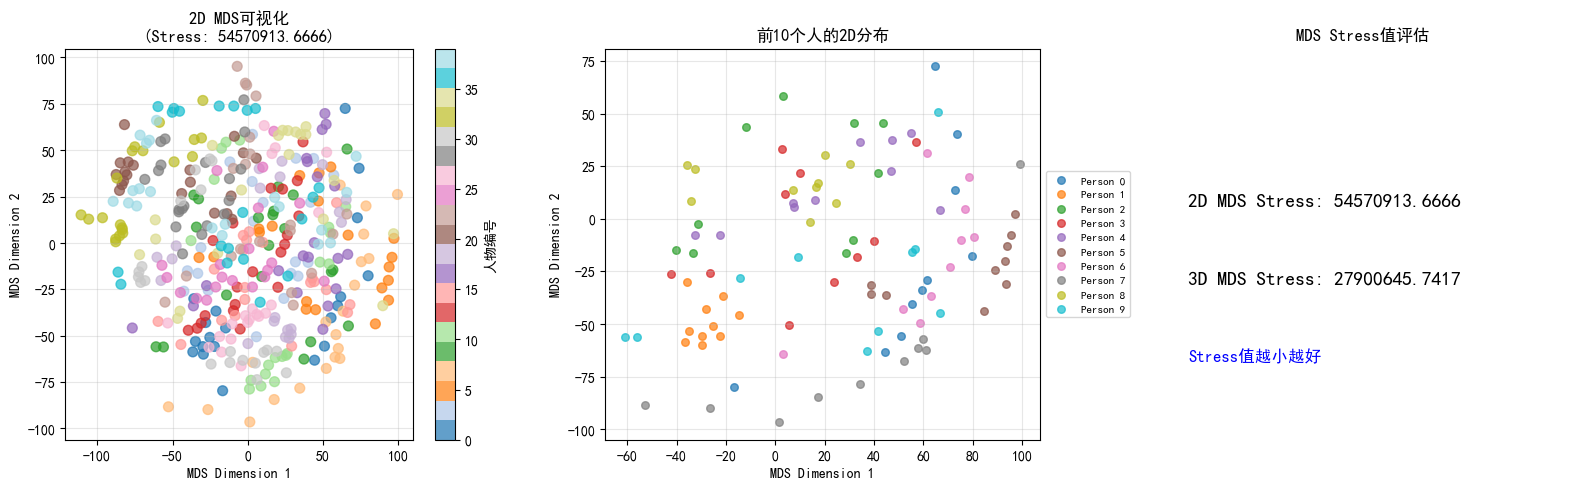

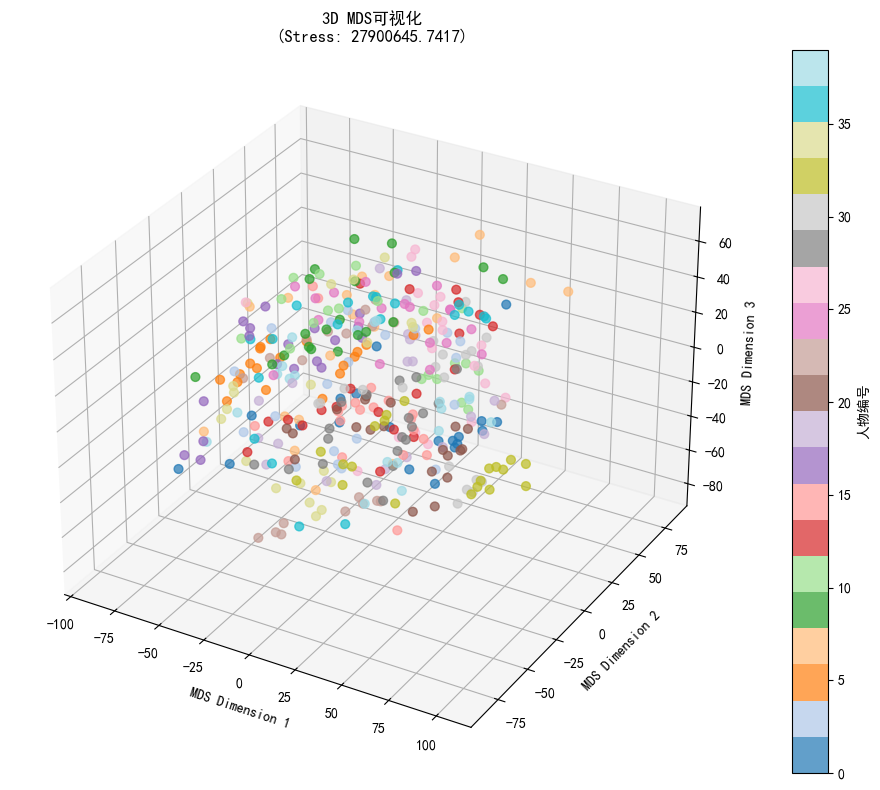


  计算维度 2
    维度  2: 准确率 = 62.50%

  计算维度 5
    维度  5: 准确率 = 89.00%

  计算维度 10
    维度 10: 准确率 = 95.25%

  计算维度 20
    维度 20: 准确率 = 98.00%

  计算维度 30
    维度 30: 准确率 = 96.75%


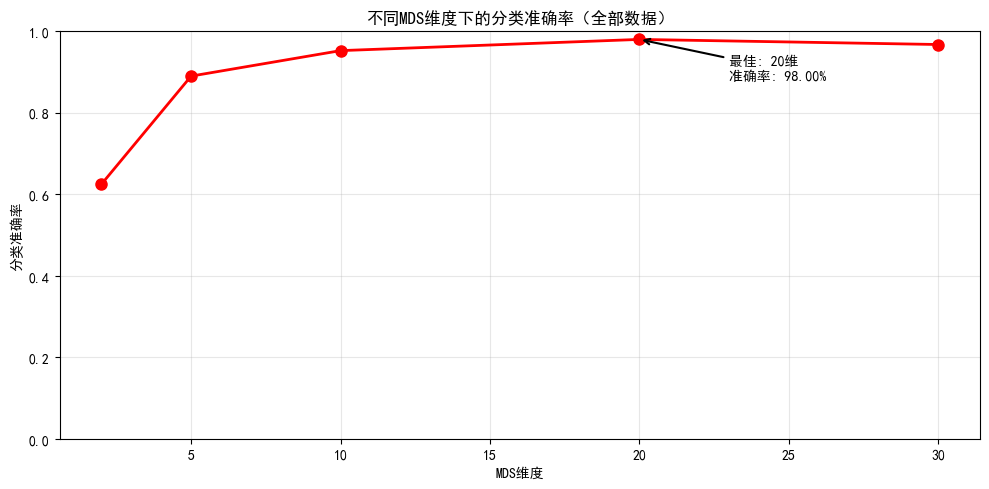

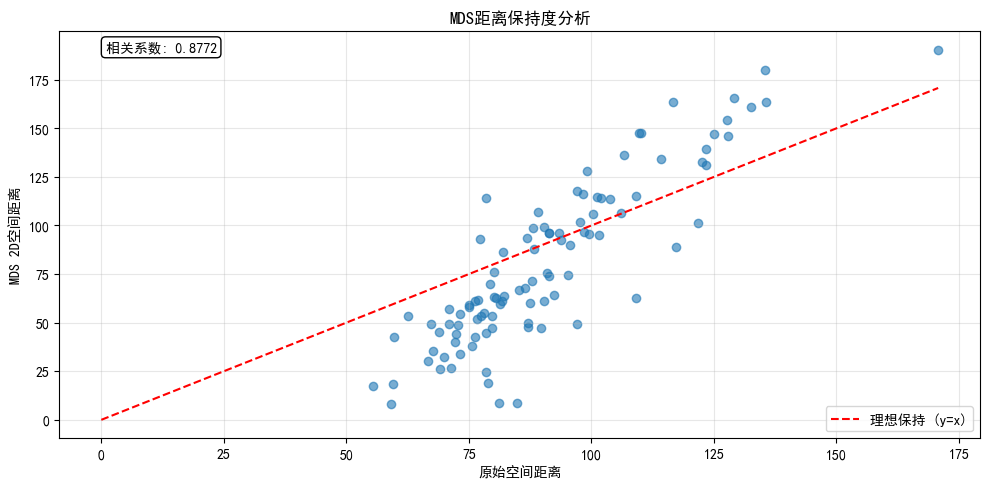


原始距离与MDS距离的相关系数: 0.8772

【MDS vs PCA 对比】

维度 20 下的分类准确率:
  PCA: 97.50%
  MDS: 98.00%
1. 2D MDS Stress值: 54570913.6666
2. 3D MDS Stress值: 27900645.7417
3. 最佳分类维度: 20
4. 最佳分类准确率: 98.00%
5. 距离保持相关系数: 0.8772


In [20]:
#MDS
from sklearn.manifold import MDS
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import time
import warnings
warnings.filterwarnings('ignore')

# ============ 3. MDS分析 ============
print("\n【MDS降维分析】")

# 3.1 2D MDS
start_time = time.time()
mds_2d = MDS(n_components=2, random_state=42, n_init=1, max_iter=300)
X_mds_2d = mds_2d.fit_transform(X_scaled)
print(f"✓ 2D MDS完成，耗时: {time.time() - start_time:.2f}秒")
print(f"  Stress: {mds_2d.stress_:.4f}")

# 3.2 3D MDS
try:
    start_time = time.time()
    mds_3d = MDS(n_components=3, random_state=42, n_init=1, max_iter=300)
    X_mds_3d = mds_3d.fit_transform(X_scaled)
    print(f"✓ 3D MDS完成，耗时: {time.time() - start_time:.2f}秒")
    print(f"  Stress: {mds_3d.stress_:.4f}")
    has_3d = True
except Exception as e:
    print(f"⚠ 3D MDS失败: {e}")
    has_3d = False
    X_mds_3d = None

# ============ 4. 可视化 ============

# 4.1 2D MDS散点图
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
scatter = plt.scatter(X_mds_2d[:, 0], X_mds_2d[:, 1], 
                      c=y, cmap='tab20', alpha=0.7, s=50)
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title(f'2D MDS可视化\n(Stress: {mds_2d.stress_:.4f})')
plt.colorbar(scatter, label='人物编号')
plt.grid(True, alpha=0.3)

# 4.2 按人物显示（前10个人）
plt.subplot(1, 3, 2)
for i in range(10):
    mask = y == i
    plt.scatter(X_mds_2d[mask, 0], X_mds_2d[mask, 1], 
               label=f'Person {i}', alpha=0.7, s=30)
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('前10个人的2D分布')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.grid(True, alpha=0.3)

# 4.3 Stress值显示
plt.subplot(1, 3, 3)
plt.text(0.1, 0.6, f'2D MDS Stress: {mds_2d.stress_:.4f}', fontsize=14)
if has_3d:
    plt.text(0.1, 0.4, f'3D MDS Stress: {mds_3d.stress_:.4f}', fontsize=14)
plt.text(0.1, 0.2, 'Stress值越小越好', fontsize=12, color='blue')
plt.axis('off')
plt.title('MDS Stress值评估')

plt.tight_layout()
plt.show()

# 4.4 3D可视化（如果有）
if has_3d:
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(X_mds_3d[:, 0], X_mds_3d[:, 1], X_mds_3d[:, 2],
                        c=y, cmap='tab20', alpha=0.7, s=40)
    ax.set_xlabel('MDS Dimension 1')
    ax.set_ylabel('MDS Dimension 2')
    ax.set_zlabel('MDS Dimension 3')
    ax.set_title(f'3D MDS可视化\n(Stress: {mds_3d.stress_:.4f})')
    plt.colorbar(scatter, label='人物编号')
    plt.tight_layout()
    plt.show()

# ============ 5. 使用完整数据集的分类 ============
dimensions_classify = [2, 5, 10, 20, 30]
accuracies = []

for dim in dimensions_classify:
    print(f"\n  计算维度 {dim}")
    mds_clf = MDS(n_components=dim, random_state=42, n_init=1, max_iter=300)
    
    # 对整个数据集进行MDS变换
    X_mds_full = mds_clf.fit_transform(X_scaled)
    
    # 使用全部数据进行KNN（自预测）
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_mds_full, y)
    y_pred = knn.predict(X_mds_full)
    acc = accuracy_score(y, y_pred)
    accuracies.append(acc)
    print(f"    维度 {dim:2d}: 准确率 = {acc*100:.2f}%")

# 可视化分类准确率
plt.figure(figsize=(10, 5))
plt.plot(dimensions_classify, accuracies, 'ro-', linewidth=2, markersize=8)
plt.xlabel('MDS维度')
plt.ylabel('分类准确率')
plt.title('不同MDS维度下的分类准确率（全部数据）')
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])

best_idx = np.argmax(accuracies)
best_dim = dimensions_classify[best_idx]
best_acc = accuracies[best_idx]
plt.annotate(f'最佳: {best_dim}维\n准确率: {best_acc*100:.2f}%',
             xy=(best_dim, best_acc), xytext=(best_dim+3, best_acc-0.1),
             arrowprops=dict(arrowstyle='->', lw=1.5))

plt.tight_layout()
plt.show()

# ============ 6. 样本距离保持度分析 ============
n_pairs = 100
np.random.seed(42)
indices = np.random.choice(400, n_pairs*2, replace=False)
pairs = indices.reshape(n_pairs, 2)

original_distances = []
mds_distances = []

for i, j in pairs:
    orig_dist = np.linalg.norm(X_scaled[i] - X_scaled[j])
    mds_dist = np.linalg.norm(X_mds_2d[i] - X_mds_2d[j])
    original_distances.append(orig_dist)
    mds_distances.append(mds_dist)

plt.figure(figsize=(10, 5))
plt.scatter(original_distances, mds_distances, alpha=0.6)
plt.plot([0, max(original_distances)], [0, max(original_distances)], 
         'r--', label='理想保持 (y=x)')
plt.xlabel('原始空间距离')
plt.ylabel('MDS 2D空间距离')
plt.title('MDS距离保持度分析')
plt.legend()
plt.grid(True, alpha=0.3)

corr = np.corrcoef(original_distances, mds_distances)[0, 1]
plt.annotate(f'相关系数: {corr:.4f}', xy=(0.05, 0.95), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white'))

plt.tight_layout()
plt.show()

print(f"\n原始距离与MDS距离的相关系数: {corr:.4f}")

# ============ 7. MDS vs PCA对比 ============
print("\n【MDS vs PCA 对比】")

dim_compare = 20

# PCA
pca = PCA(n_components=dim_compare)
X_pca = pca.fit_transform(X_scaled)

# MDS
mds_compare = MDS(n_components=dim_compare, random_state=42, n_init=1, max_iter=300)
X_mds_compare = mds_compare.fit_transform(X_scaled)

# 使用KNN对比
knn = KNeighborsClassifier(n_neighbors=3)

# 使用全部数据
knn.fit(X_pca, y)
pca_acc = accuracy_score(y, knn.predict(X_pca))

knn.fit(X_mds_compare, y)
mds_acc = accuracy_score(y, knn.predict(X_mds_compare))

print(f"\n维度 {dim_compare} 下的分类准确率:")
print(f"  PCA: {pca_acc*100:.2f}%")
print(f"  MDS: {mds_acc*100:.2f}%")

print(f"1. 2D MDS Stress值: {mds_2d.stress_:.4f}")
if has_3d:
    print(f"2. 3D MDS Stress值: {mds_3d.stress_:.4f}")
print(f"3. 最佳分类维度: {best_dim}")
print(f"4. 最佳分类准确率: {best_acc*100:.2f}%")
print(f"5. 距离保持相关系数: {corr:.4f}")


【KPCA降维分析】

  使用 linear 核函数
    完成，耗时: 0.11秒

  使用 poly 核函数
    完成，耗时: 0.11秒

  使用 rbf 核函数
    完成，耗时: 0.17秒

  使用 sigmoid 核函数
    完成，耗时: 0.12秒

【2D可视化】


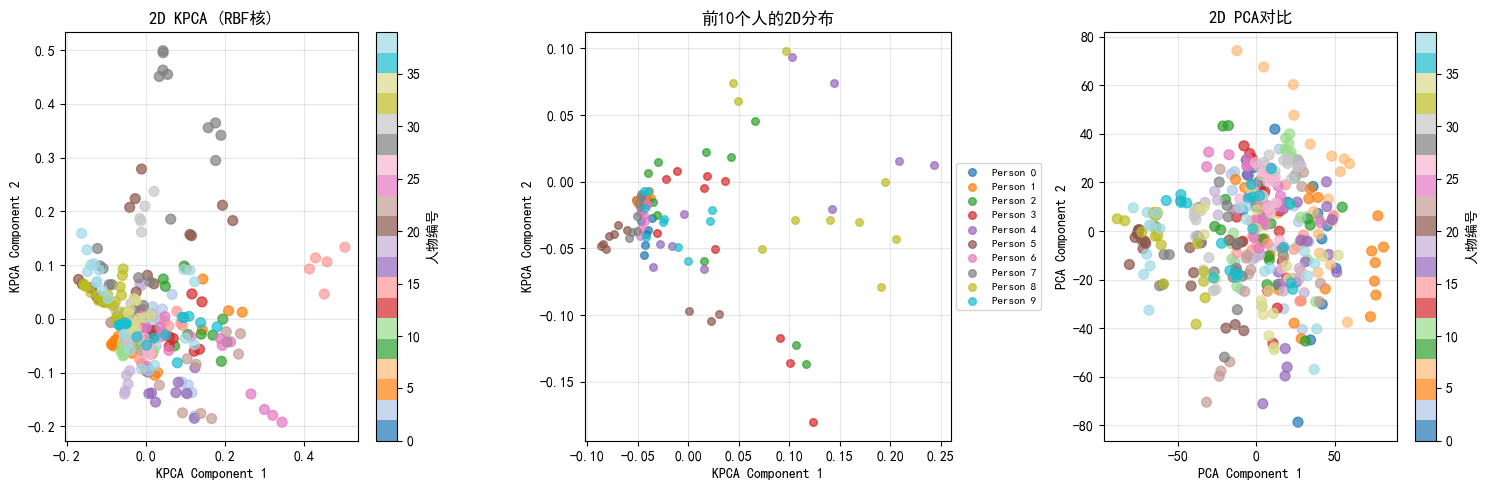


【不同核函数性能对比】


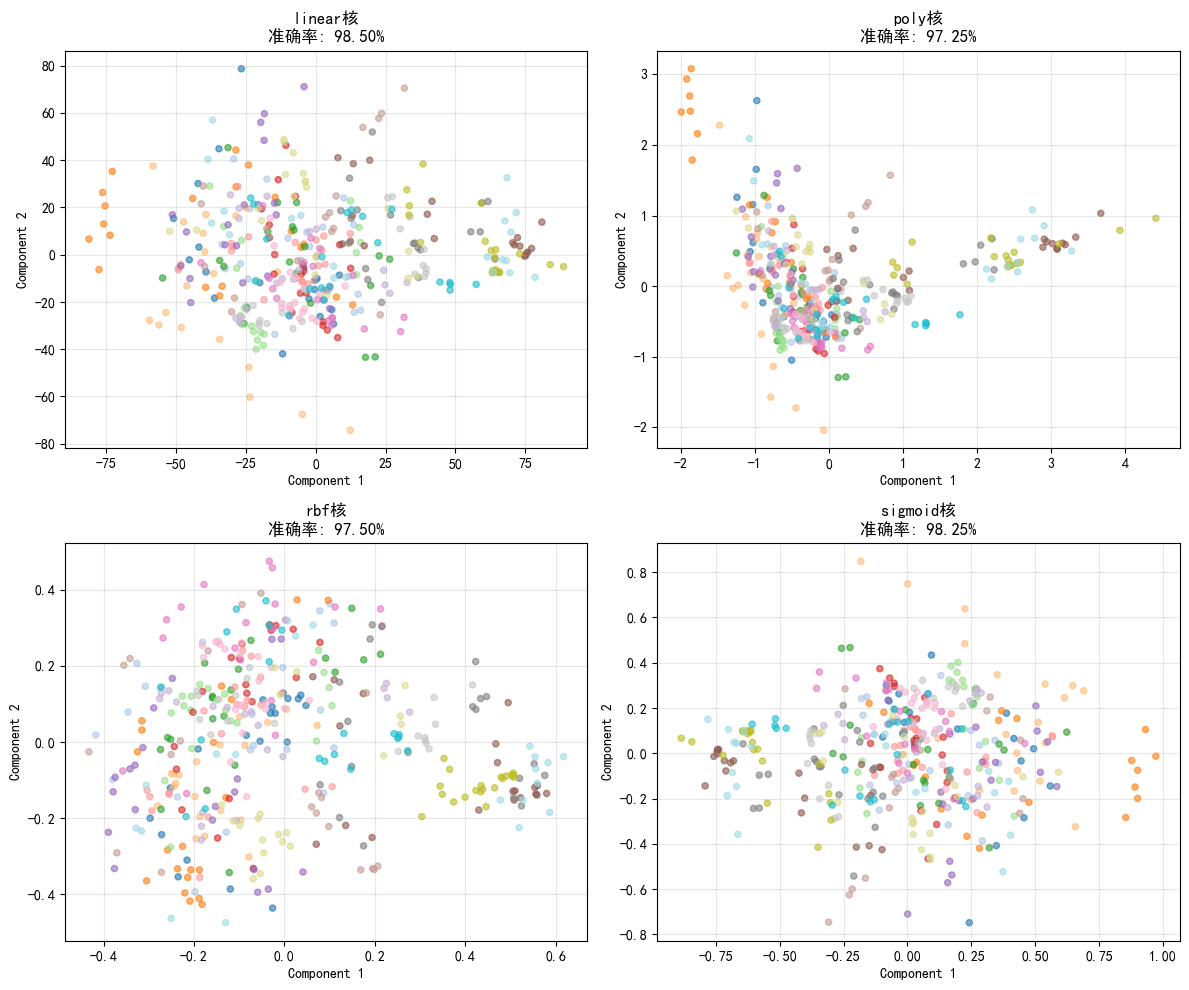


【RBF核参数调优】
  gamma值  |  准确率  |  耗时(秒)
  ---------|----------|----------
    0.0001  |   97.50%  |    0.17s
    0.0005  |   95.75%  |    0.18s
    0.0010  |   92.00%  |    0.18s
    0.0050  |   64.00%  |    0.18s
    0.0100  |   62.50%  |    0.18s
    0.0500  |   48.75%  |    0.17s
    0.1000  |  失败: Internal Error.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

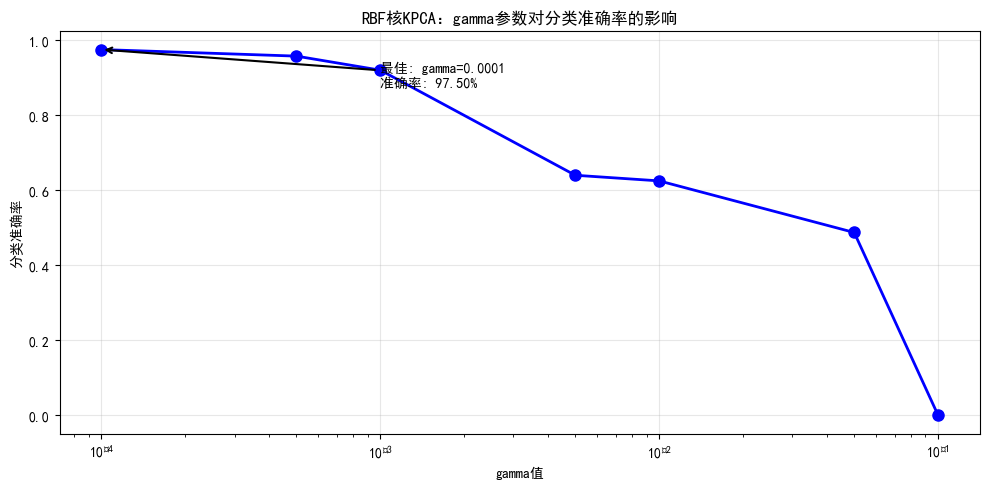


【不同维度对比】
  计算维度 10
    维度  10: 准确率 = 86.00%
  计算维度 20
    维度  20: 准确率 = 91.50%
  计算维度 30
    维度  30: 准确率 = 92.00%
  计算维度 50
    维度  50: 准确率 = 93.00%
  计算维度 80
    维度  80: 准确率 = 93.50%
  计算维度 100
    维度 100: 准确率 = 93.50%


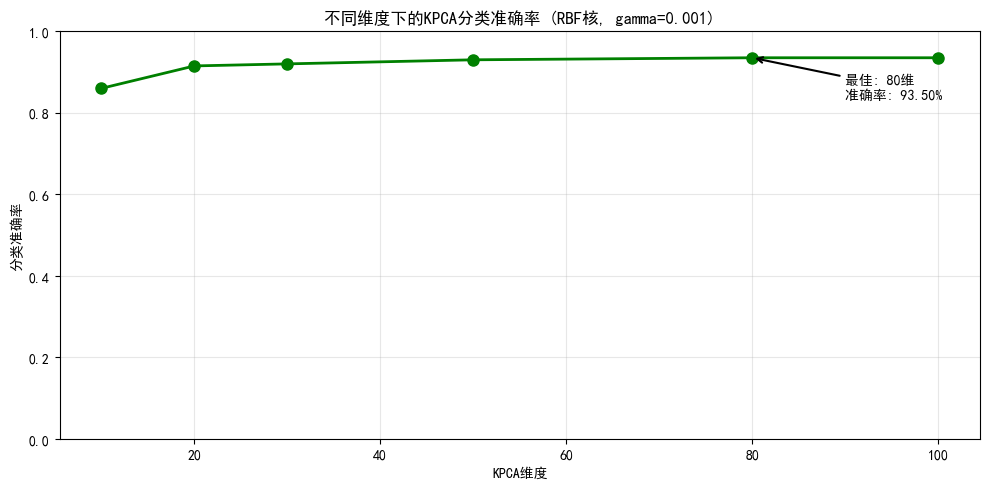


【KPCA vs PCA 对比】

维度 50 下的5折交叉验证准确率:
  KPCA (RBF核): 76.75%
  PCA:          88.50%


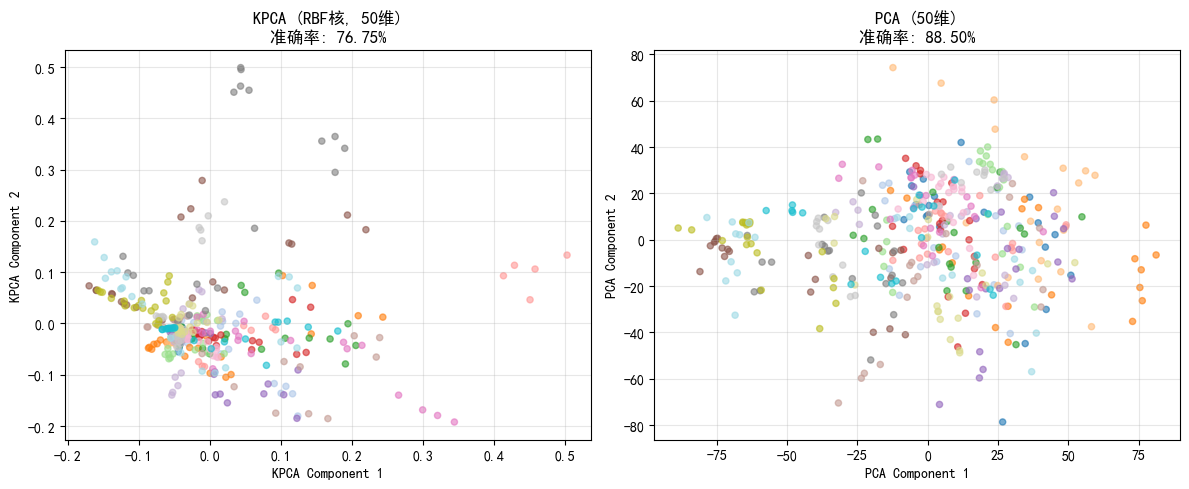

1. 最佳核函数: RBF核 (gamma=0.0001)
2. 最佳维度: 80
3. 最佳分类准确率: 93.50%
4. 与PCA对比 (50维):
   KPCA: 76.75%
   PCA:  88.50%


In [28]:
##KPCA
from sklearn.decomposition import KernelPCA
warnings.filterwarnings('ignore') 

# ============ 3. KPCA分析（不同核函数） ============
print("\n【KPCA降维分析】")

# 3.1 不同核函数对比
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
n_components = 50  # 降维到50维

kpca_results = {}
kpca_time = {}

for kernel in kernels:
    print(f"\n  使用 {kernel} 核函数")
    try:
        start_time = time.time()
        kpca = KernelPCA(n_components=n_components, kernel=kernel, 
                         random_state=42, n_jobs=-1)
        X_kpca = kpca.fit_transform(X_scaled)
        elapsed = time.time() - start_time
        kpca_time[kernel] = elapsed
        kpca_results[kernel] = X_kpca
        print(f"    完成，耗时: {elapsed:.2f}秒")
    except Exception as e:
        print(f"    失败: {e}")
        kpca_results[kernel] = None

# ============ 4. 可视化不同核函数的效果 ============

# 4.1 2D可视化（使用rbf核）
print("\n【2D可视化】")
kpca_2d = KernelPCA(n_components=2, kernel='rbf', gamma=0.001, random_state=42)
X_kpca_2d = kpca_2d.fit_transform(X_scaled)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
scatter = plt.scatter(X_kpca_2d[:, 0], X_kpca_2d[:, 1], 
                      c=y, cmap='tab20', alpha=0.7, s=50)
plt.xlabel('KPCA Component 1')
plt.ylabel('KPCA Component 2')
plt.title('2D KPCA (RBF核)')
plt.colorbar(scatter, label='人物编号')
plt.grid(True, alpha=0.3)

# 4.2 显示前10个人
plt.subplot(1, 3, 2)
for i in range(10):
    mask = y == i
    plt.scatter(X_kpca_2d[mask, 0], X_kpca_2d[mask, 1], 
               label=f'Person {i}', alpha=0.7, s=30)
plt.xlabel('KPCA Component 1')
plt.ylabel('KPCA Component 2')
plt.title('前10个人的2D分布')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.grid(True, alpha=0.3)

# 4.3 与PCA对比
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.subplot(1, 3, 3)
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                      c=y, cmap='tab20', alpha=0.7, s=50)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('2D PCA对比')
plt.colorbar(scatter, label='人物编号')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============ 5. 不同核函数性能对比 ============
print("\n【不同核函数性能对比】")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, kernel in enumerate(kernels):
    if kpca_results[kernel] is not None:
        X_kpca = kpca_results[kernel]
        # 使用KNN评估
        knn = KNeighborsClassifier(n_neighbors=3)
        knn.fit(X_kpca, y)
        y_pred = knn.predict(X_kpca)
        acc = accuracy_score(y, y_pred)
        
        # 可视化前两个主成分
        axes[idx].scatter(X_kpca[:, 0], X_kpca[:, 1], 
                         c=y, cmap='tab20', alpha=0.6, s=20)
        axes[idx].set_title(f'{kernel}核\n准确率: {acc*100:.2f}%')
        axes[idx].set_xlabel('Component 1')
        axes[idx].set_ylabel('Component 2')
        axes[idx].grid(True, alpha=0.3)
    else:
        axes[idx].text(0.5, 0.5, f'{kernel}核\n失败', 
                      ha='center', va='center', fontsize=14)
        axes[idx].set_title(f'{kernel}核')

plt.tight_layout()
plt.show()

# ============ 6. 参数调优：不同gamma值（RBF核） ============
print("\n【RBF核参数调优】")

gamma_values = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
gamma_accuracies = []
n_components_param = 30

print("  gamma值  |  准确率  |  耗时(秒)")
print("  ---------|----------|----------")

for gamma in gamma_values:
    try:
        start_time = time.time()
        kpca = KernelPCA(n_components=n_components_param, kernel='rbf', 
                         gamma=gamma, random_state=42, n_jobs=-1)
        X_kpca = kpca.fit_transform(X_scaled)
        elapsed = time.time() - start_time
        
        knn = KNeighborsClassifier(n_neighbors=3)
        knn.fit(X_kpca, y)
        acc = accuracy_score(y, knn.predict(X_kpca))
        gamma_accuracies.append(acc)
        print(f"  {gamma:8.4f}  |  {acc*100:6.2f}%  |  {elapsed:6.2f}s")
    except Exception as e:
        print(f"  {gamma:8.4f}  |  失败: {e}")
        gamma_accuracies.append(0)

# 可视化gamma影响
plt.figure(figsize=(10, 5))
plt.plot(gamma_values, gamma_accuracies, 'bo-', linewidth=2, markersize=8)
plt.xlabel('gamma值')
plt.ylabel('分类准确率')
plt.title('RBF核KPCA：gamma参数对分类准确率的影响')
plt.grid(True, alpha=0.3)
plt.xscale('log')

best_idx = np.argmax(gamma_accuracies)
best_gamma = gamma_values[best_idx]
best_acc = gamma_accuracies[best_idx]
plt.annotate(f'最佳: gamma={best_gamma}\n准确率: {best_acc*100:.2f}%',
             xy=(best_gamma, best_acc), xytext=(best_gamma*10, best_acc-0.1),
             arrowprops=dict(arrowstyle='->', lw=1.5))

plt.tight_layout()
plt.show()

# ============ 7. 不同维度对比 ============
print("\n【不同维度对比】")

dimensions = [10, 20, 30, 50, 80, 100]
dim_accuracies = []

for dim in dimensions:
    print(f"  计算维度 {dim}")
    try:
        kpca = KernelPCA(n_components=dim, kernel='rbf', 
                         gamma=0.001, random_state=42, n_jobs=-1)
        X_kpca = kpca.fit_transform(X_scaled)
        
        knn = KNeighborsClassifier(n_neighbors=3)
        knn.fit(X_kpca, y)
        acc = accuracy_score(y, knn.predict(X_kpca))
        dim_accuracies.append(acc)
        print(f"    维度 {dim:3d}: 准确率 = {acc*100:.2f}%")
    except Exception as e:
        print(f"    维度 {dim:3d}: 失败 - {e}")
        dim_accuracies.append(0)

# 可视化维度影响
plt.figure(figsize=(10, 5))
plt.plot(dimensions, dim_accuracies, 'go-', linewidth=2, markersize=8)
plt.xlabel('KPCA维度')
plt.ylabel('分类准确率')
plt.title('不同维度下的KPCA分类准确率 (RBF核, gamma=0.001)')
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])

best_idx = np.argmax(dim_accuracies)
best_dim = dimensions[best_idx]
best_acc = dim_accuracies[best_idx]
plt.annotate(f'最佳: {best_dim}维\n准确率: {best_acc*100:.2f}%',
             xy=(best_dim, best_acc), xytext=(best_dim+10, best_acc-0.1),
             arrowprops=dict(arrowstyle='->', lw=1.5))

plt.tight_layout()
plt.show()

# ============ 8. KPCA vs PCA 对比 ============
print("\n【KPCA vs PCA 对比】")

dim_compare = 50

# KPCA (RBF核)
kpca_compare = KernelPCA(n_components=dim_compare, kernel='rbf', 
                         gamma=0.001, random_state=42)
X_kpca_compare = kpca_compare.fit_transform(X_scaled)

# PCA
pca_compare = PCA(n_components=dim_compare)
X_pca_compare = pca_compare.fit_transform(X_scaled)

# 分类评估
knn = KNeighborsClassifier(n_neighbors=3)

kpca_acc = cross_val_score(knn, X_kpca_compare, y, cv=5).mean()
pca_acc = cross_val_score(knn, X_pca_compare, y, cv=5).mean()

print(f"\n维度 {dim_compare} 下的5折交叉验证准确率:")
print(f"  KPCA (RBF核): {kpca_acc*100:.2f}%")
print(f"  PCA:          {pca_acc*100:.2f}%")

# ============ 9. 可视化KPCA vs PCA ============
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_kpca_compare[:, 0], X_kpca_compare[:, 1], 
           c=y, cmap='tab20', alpha=0.6, s=20)
plt.xlabel('KPCA Component 1')
plt.ylabel('KPCA Component 2')
plt.title(f'KPCA (RBF核, {dim_compare}维)\n准确率: {kpca_acc*100:.2f}%')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_pca_compare[:, 0], X_pca_compare[:, 1], 
           c=y, cmap='tab20', alpha=0.6, s=20)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'PCA ({dim_compare}维)\n准确率: {pca_acc*100:.2f}%')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"1. 最佳核函数: RBF核 (gamma={best_gamma})")
print(f"2. 最佳维度: {best_dim}")
print(f"3. 最佳分类准确率: {best_acc*100:.2f}%")
print(f"4. 与PCA对比 ({dim_compare}维):")
print(f"   KPCA: {kpca_acc*100:.2f}%")
print(f"   PCA:  {pca_acc*100:.2f}%")

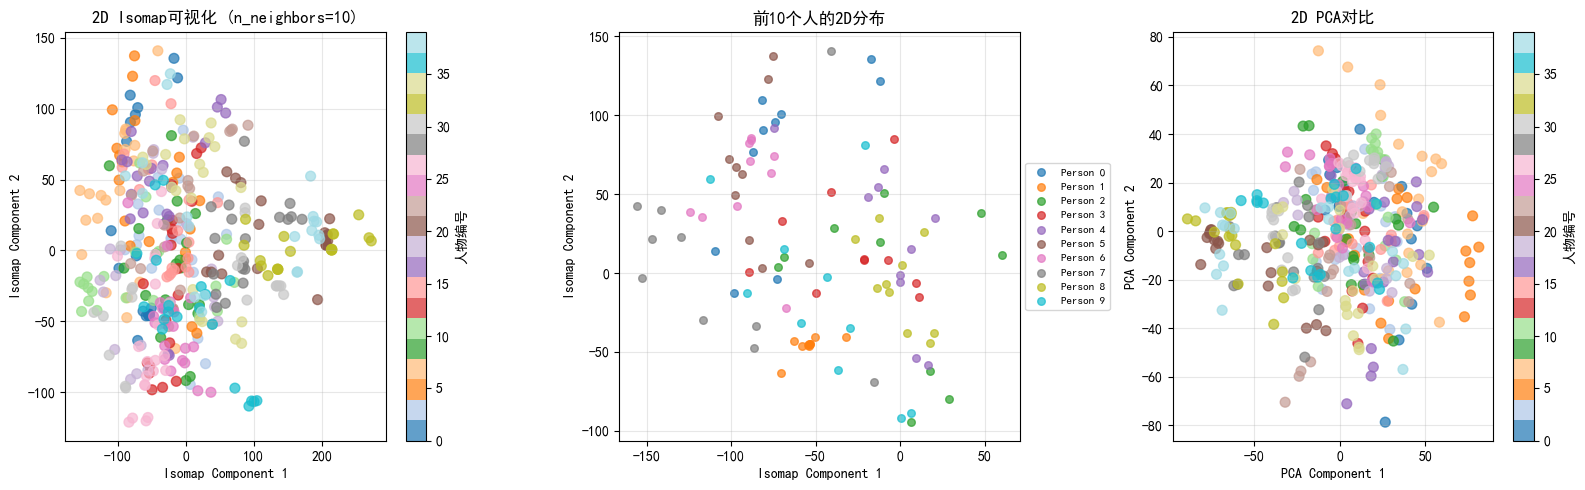

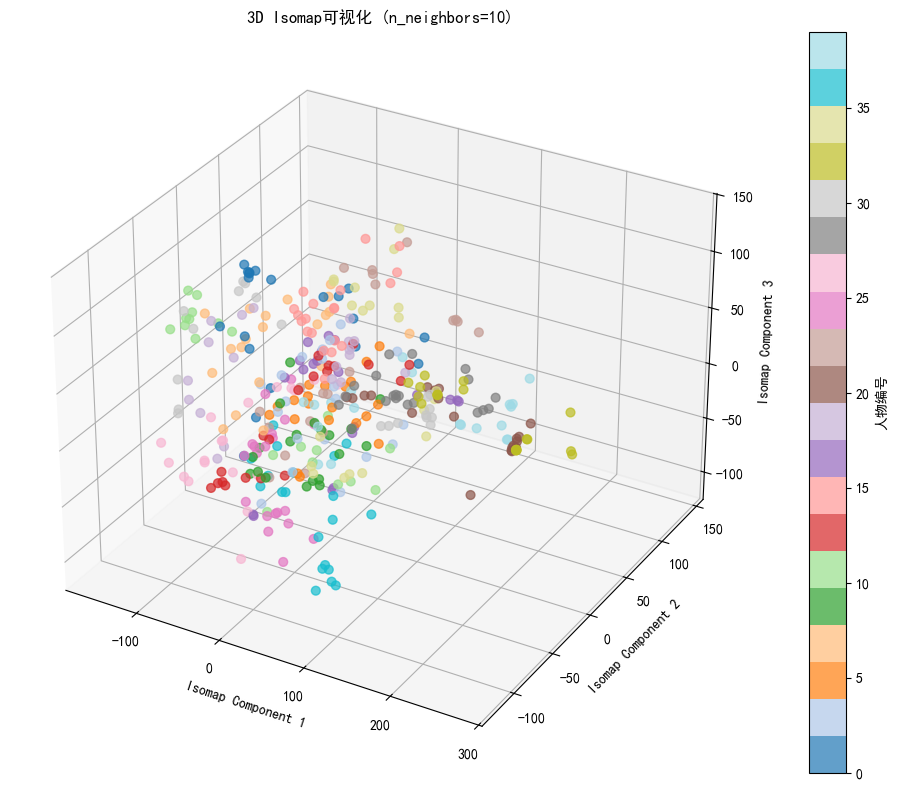


【不同n_neighbors参数对比】
  n_neighbors |  准确率  |  耗时(秒)
  ------------|----------|----------
           5  |   91.00%  |    0.12s
          10  |   92.50%  |    0.11s
          15  |   92.00%  |    0.11s
          20  |   91.50%  |    0.12s
          30  |   90.50%  |    0.12s
          50  |   94.25%  |    0.14s


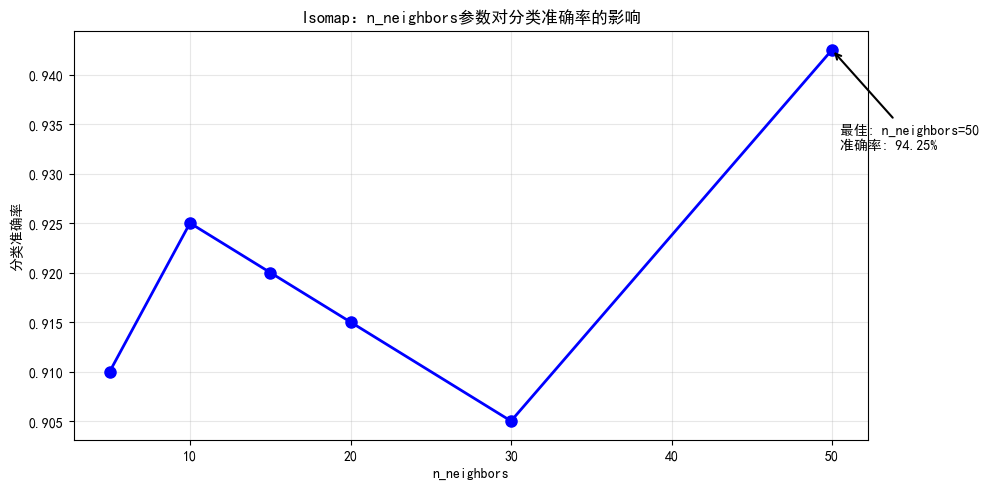


【不同维度对比】
  计算维度 5
    维度   5: 准确率 = 83.00%
  计算维度 10
    维度  10: 准确率 = 89.50%
  计算维度 20
    维度  20: 准确率 = 92.50%
  计算维度 30
    维度  30: 准确率 = 92.75%
  计算维度 50
    维度  50: 准确率 = 93.50%
  计算维度 80
    维度  80: 准确率 = 92.75%


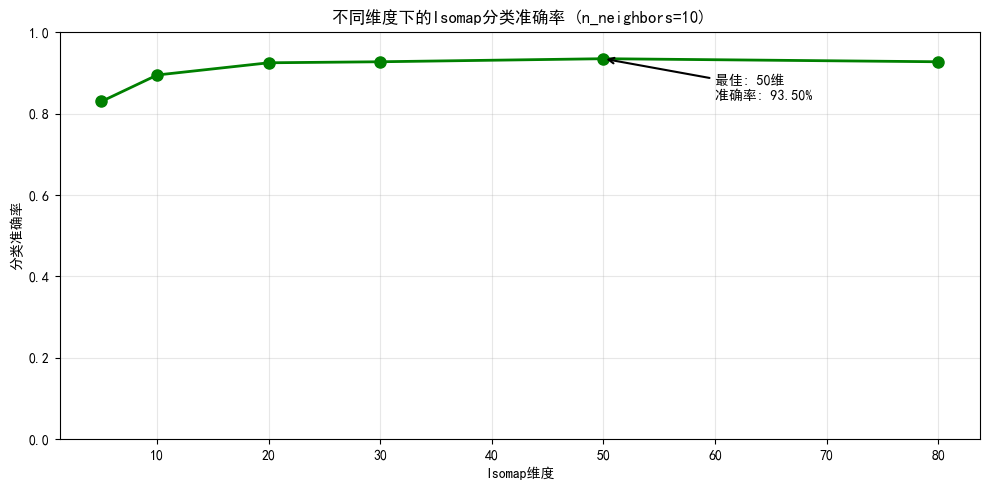


【Isomap vs PCA 对比】

维度 20 下的5折交叉验证准确率:
  Isomap: 75.25%
  PCA:    83.75%


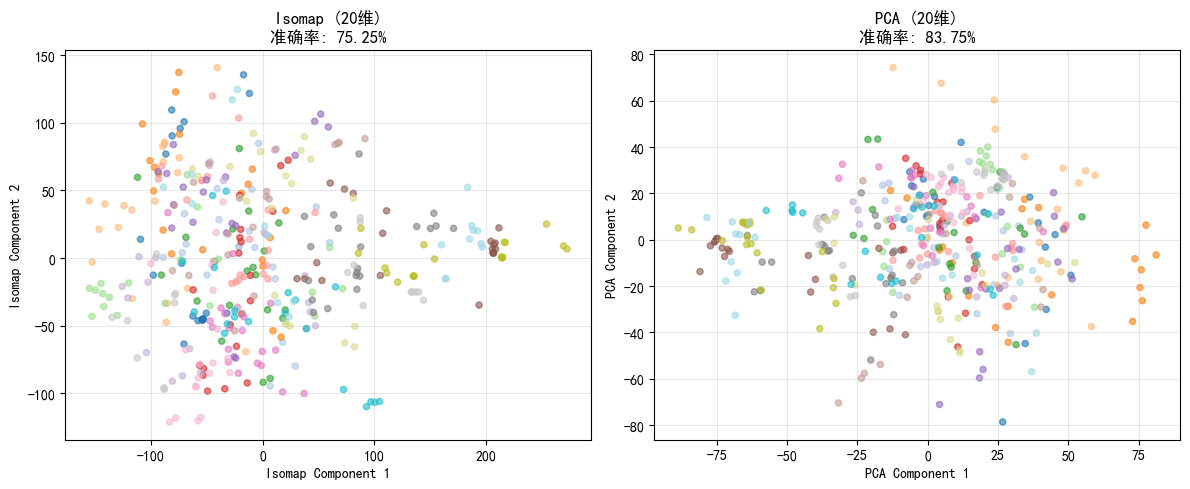


【测地距离保持度分析】


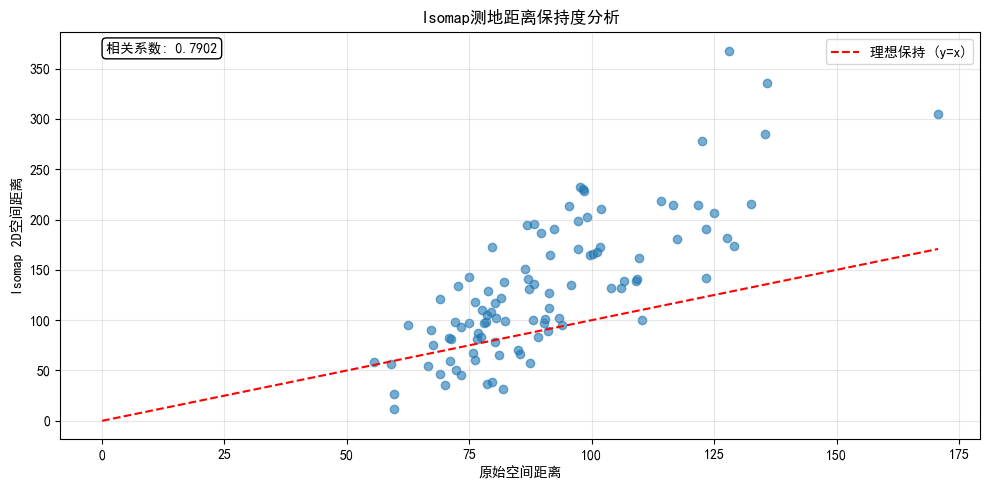


原始距离与Isomap距离的相关系数: 0.7902
1. 最佳n_neighbors: 50
2. 最佳维度: 50
3. 最佳分类准确率: 93.50%
4. 与PCA对比 (20维):
   Isomap: 75.25%
   PCA:    83.75%
5. 距离保持相关系数: 0.7902


In [38]:
#Isomap
from sklearn.manifold import Isomap

# ============ 3. Isomap分析 ============
# 3.1 2D Isomap
start_time = time.time()
isomap_2d = Isomap(n_components=2, n_neighbors=10, n_jobs=-1)
X_isomap_2d = isomap_2d.fit_transform(X_scaled)

# 3.2 3D Isomap
try:
    start_time = time.time()
    isomap_3d = Isomap(n_components=3, n_neighbors=10, n_jobs=-1)
    X_isomap_3d = isomap_3d.fit_transform(X_scaled)
    has_3d = True
except Exception as e:
    print(f"3D Isomap失败: {e}")
    has_3d = False
    X_isomap_3d = None

# ============ 4. 可视化 ============

# 4.1 2D Isomap散点图
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
scatter = plt.scatter(X_isomap_2d[:, 0], X_isomap_2d[:, 1], 
                      c=y, cmap='tab20', alpha=0.7, s=50)
plt.xlabel('Isomap Component 1')
plt.ylabel('Isomap Component 2')
plt.title('2D Isomap可视化 (n_neighbors=10)')
plt.colorbar(scatter, label='人物编号')
plt.grid(True, alpha=0.3)

# 4.2 前10个人
plt.subplot(1, 3, 2)
for i in range(10):
    mask = y == i
    plt.scatter(X_isomap_2d[mask, 0], X_isomap_2d[mask, 1], 
               label=f'Person {i}', alpha=0.7, s=30)
plt.xlabel('Isomap Component 1')
plt.ylabel('Isomap Component 2')
plt.title('前10个人的2D分布')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.grid(True, alpha=0.3)

# 4.3 与PCA对比
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.subplot(1, 3, 3)
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                      c=y, cmap='tab20', alpha=0.7, s=50)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('2D PCA对比')
plt.colorbar(scatter, label='人物编号')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4.4 3D可视化（如果有）
if has_3d:
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(X_isomap_3d[:, 0], X_isomap_3d[:, 1], X_isomap_3d[:, 2],
                        c=y, cmap='tab20', alpha=0.7, s=40)
    ax.set_xlabel('Isomap Component 1')
    ax.set_ylabel('Isomap Component 2')
    ax.set_zlabel('Isomap Component 3')
    ax.set_title('3D Isomap可视化 (n_neighbors=10)')
    plt.colorbar(scatter, label='人物编号')
    plt.tight_layout()
    plt.show()

# ============ 5. 不同neighbors参数对比 ============
print("\n【不同n_neighbors参数对比】")

neighbors_list = [5, 10, 15, 20, 30, 50]
neighbors_accuracies = []

print("  n_neighbors |  准确率  |  耗时(秒)")
print("  ------------|----------|----------")

for n_neigh in neighbors_list:
    try:
        start_time = time.time()
        isomap = Isomap(n_components=20, n_neighbors=n_neigh, n_jobs=-1)
        X_isomap = isomap.fit_transform(X_scaled)
        elapsed = time.time() - start_time
        
        knn = KNeighborsClassifier(n_neighbors=3)
        knn.fit(X_isomap, y)
        acc = accuracy_score(y, knn.predict(X_isomap))
        neighbors_accuracies.append(acc)
        print(f"  {n_neigh:10d}  |  {acc*100:6.2f}%  |  {elapsed:6.2f}s")
    except Exception as e:
        print(f"  {n_neigh:10d}  |  失败: {e}")
        neighbors_accuracies.append(0)

# 可视化neighbors影响
plt.figure(figsize=(10, 5))
plt.plot(neighbors_list, neighbors_accuracies, 'bo-', linewidth=2, markersize=8)
plt.xlabel('n_neighbors')
plt.ylabel('分类准确率')
plt.title('Isomap：n_neighbors参数对分类准确率的影响')
plt.grid(True, alpha=0.3)

best_idx = np.argmax(neighbors_accuracies)
best_neigh = neighbors_list[best_idx]
best_acc = neighbors_accuracies[best_idx]
plt.annotate(f'最佳: n_neighbors={best_neigh}\n准确率: {best_acc*100:.2f}%',
             xy=(best_neigh, best_acc), xytext=(best_neigh+0.5, best_acc-0.01),
             arrowprops=dict(arrowstyle='->', lw=1.5))

plt.tight_layout()
plt.show()

# ============ 6. 不同维度对比 ============
print("\n【不同维度对比】")

dimensions = [5, 10, 20, 30, 50, 80]
dim_accuracies = []

for dim in dimensions:
    print(f"  计算维度 {dim}")
    try:
        isomap = Isomap(n_components=dim, n_neighbors=10, n_jobs=-1)
        X_isomap = isomap.fit_transform(X_scaled)
        
        knn = KNeighborsClassifier(n_neighbors=3)
        knn.fit(X_isomap, y)
        acc = accuracy_score(y, knn.predict(X_isomap))
        dim_accuracies.append(acc)
        print(f"    维度 {dim:3d}: 准确率 = {acc*100:.2f}%")
    except Exception as e:
        print(f"    维度 {dim:3d}: 失败 - {e}")
        dim_accuracies.append(0)

# 可视化维度影响
plt.figure(figsize=(10, 5))
plt.plot(dimensions, dim_accuracies, 'go-', linewidth=2, markersize=8)
plt.xlabel('Isomap维度')
plt.ylabel('分类准确率')
plt.title('不同维度下的Isomap分类准确率 (n_neighbors=10)')
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])

best_idx = np.argmax(dim_accuracies)
best_dim = dimensions[best_idx]
best_acc = dim_accuracies[best_idx]
plt.annotate(f'最佳: {best_dim}维\n准确率: {best_acc*100:.2f}%',
             xy=(best_dim, best_acc), xytext=(best_dim+10, best_acc-0.1),
             arrowprops=dict(arrowstyle='->', lw=1.5))

plt.tight_layout()
plt.show()

# ============ 7. Isomap vs PCA 对比 ============
print("\n【Isomap vs PCA 对比】")

dim_compare = 20

# Isomap
isomap_compare = Isomap(n_components=dim_compare, n_neighbors=10, n_jobs=-1)
X_isomap_compare = isomap_compare.fit_transform(X_scaled)

# PCA
pca_compare = PCA(n_components=dim_compare)
X_pca_compare = pca_compare.fit_transform(X_scaled)

# 分类评估
knn = KNeighborsClassifier(n_neighbors=3)

isomap_acc = cross_val_score(knn, X_isomap_compare, y, cv=5).mean()
pca_acc = cross_val_score(knn, X_pca_compare, y, cv=5).mean()

print(f"\n维度 {dim_compare} 下的5折交叉验证准确率:")
print(f"  Isomap: {isomap_acc*100:.2f}%")
print(f"  PCA:    {pca_acc*100:.2f}%")

# 可视化对比
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_isomap_compare[:, 0], X_isomap_compare[:, 1], 
           c=y, cmap='tab20', alpha=0.6, s=20)
plt.xlabel('Isomap Component 1')
plt.ylabel('Isomap Component 2')
plt.title(f'Isomap ({dim_compare}维)\n准确率: {isomap_acc*100:.2f}%')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_pca_compare[:, 0], X_pca_compare[:, 1], 
           c=y, cmap='tab20', alpha=0.6, s=20)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'PCA ({dim_compare}维)\n准确率: {pca_acc*100:.2f}%')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============ 8. 距离保持度分析 ============
print("\n【测地距离保持度分析】")

# 随机选择样本对
n_pairs = 100
np.random.seed(42)
indices = np.random.choice(400, n_pairs*2, replace=False)
pairs = indices.reshape(n_pairs, 2)

original_distances = []
isomap_distances = []

for i, j in pairs:
    orig_dist = np.linalg.norm(X_scaled[i] - X_scaled[j])
    isomap_dist = np.linalg.norm(X_isomap_2d[i] - X_isomap_2d[j])
    original_distances.append(orig_dist)
    isomap_distances.append(isomap_dist)

plt.figure(figsize=(10, 5))
plt.scatter(original_distances, isomap_distances, alpha=0.6)
plt.plot([0, max(original_distances)], [0, max(original_distances)], 
         'r--', label='理想保持 (y=x)')
plt.xlabel('原始空间距离')
plt.ylabel('Isomap 2D空间距离')
plt.title('Isomap测地距离保持度分析')
plt.legend()
plt.grid(True, alpha=0.3)

corr = np.corrcoef(original_distances, isomap_distances)[0, 1]
plt.annotate(f'相关系数: {corr:.4f}', xy=(0.05, 0.95), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white'))

plt.tight_layout()
plt.show()

print(f"\n原始距离与Isomap距离的相关系数: {corr:.4f}")

# ============ 9. 总结 ============
print(f"1. 最佳n_neighbors: {best_neigh}")
print(f"2. 最佳维度: {best_dim}")
print(f"3. 最佳分类准确率: {best_acc*100:.2f}%")
print(f"4. 与PCA对比 ({dim_compare}维):")
print(f"   Isomap: {isomap_acc*100:.2f}%")
print(f"   PCA:    {pca_acc*100:.2f}%")
print(f"5. 距离保持相关系数: {corr:.4f}")


【t-SNE降维分析】
注意：t-SNE只能降维到2D或3D（Barnes-Hut算法限制）
高维降维建议使用PCA、Isomap等方法

执行 2D t-SNE (perplexity=30)

执行 3D t-SNE (perplexity=30)

执行不同perplexity的2D t-SNE
  perplexity=5 完成
  perplexity=10 完成
  perplexity=20 完成
  perplexity=30 完成
  perplexity=40 完成
  perplexity=50 完成


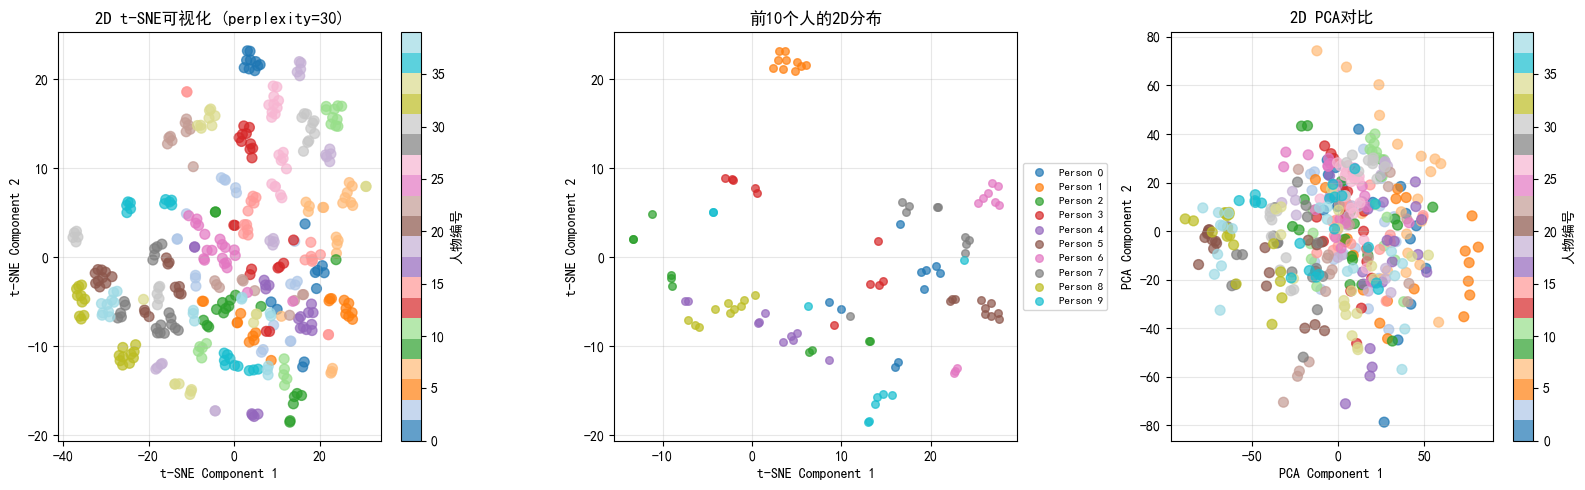

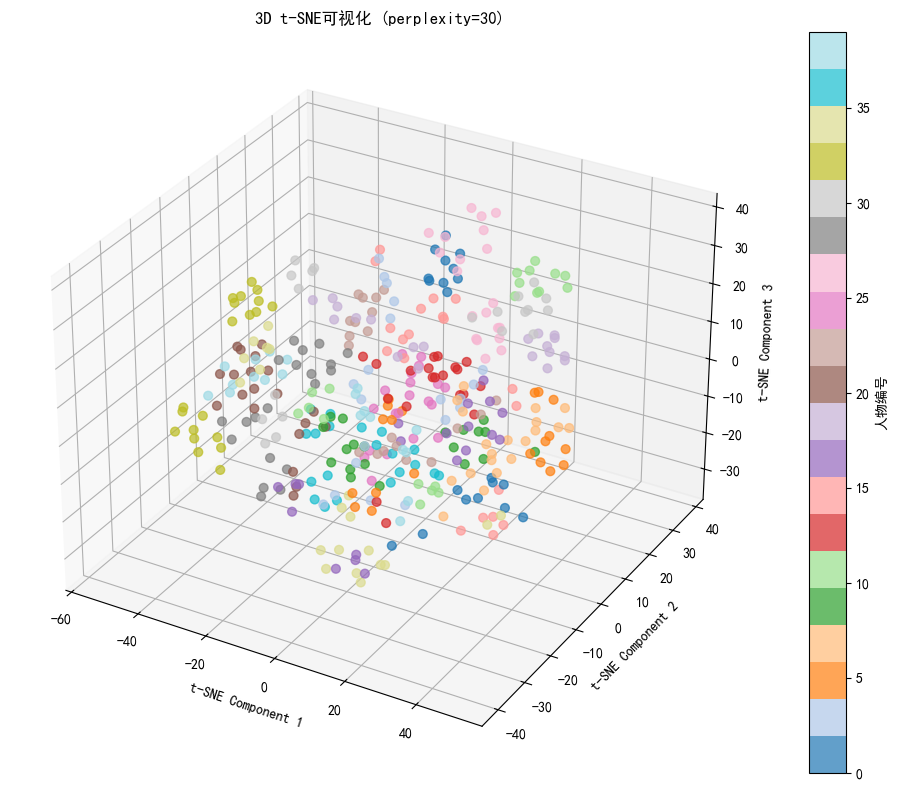


【不同perplexity可视化对比】


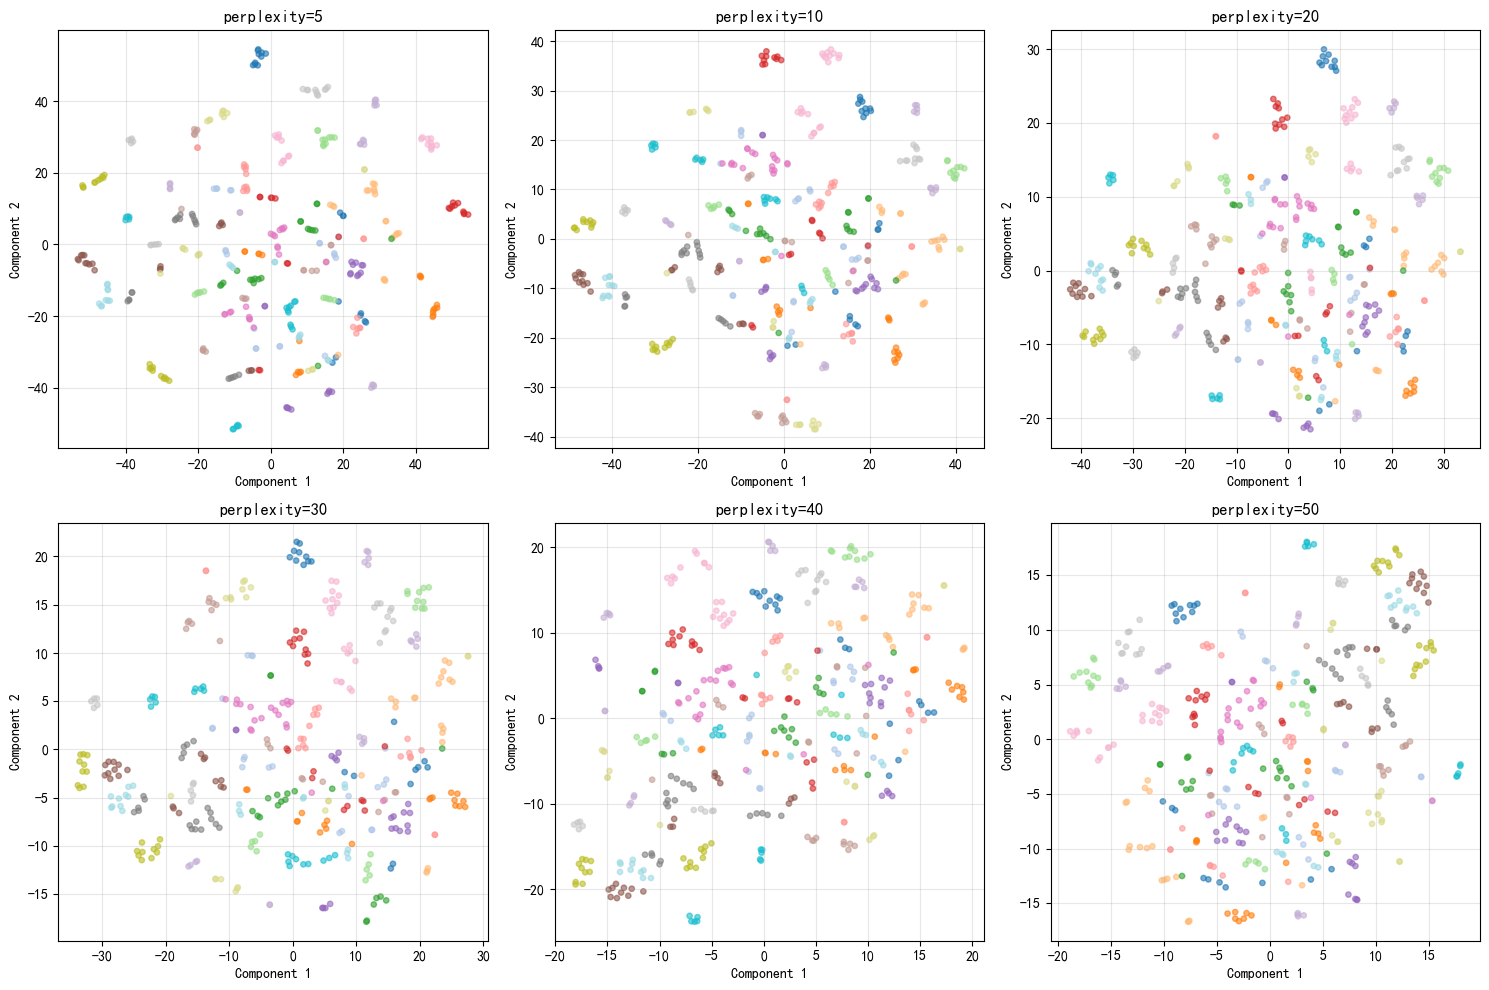


【不同perplexity聚类效果评估】
  perplexity= 5: 准确率 = 96.00%
  perplexity=10: 准确率 = 95.75%
  perplexity=20: 准确率 = 96.50%
  perplexity=30: 准确率 = 97.00%
  perplexity=40: 准确率 = 95.00%
  perplexity=50: 准确率 = 95.50%


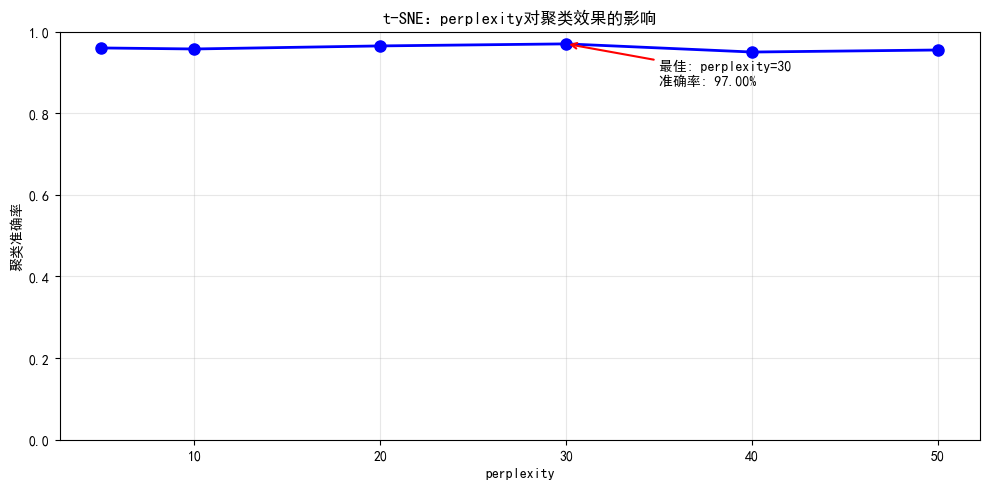


【t-SNE聚类效果展示】


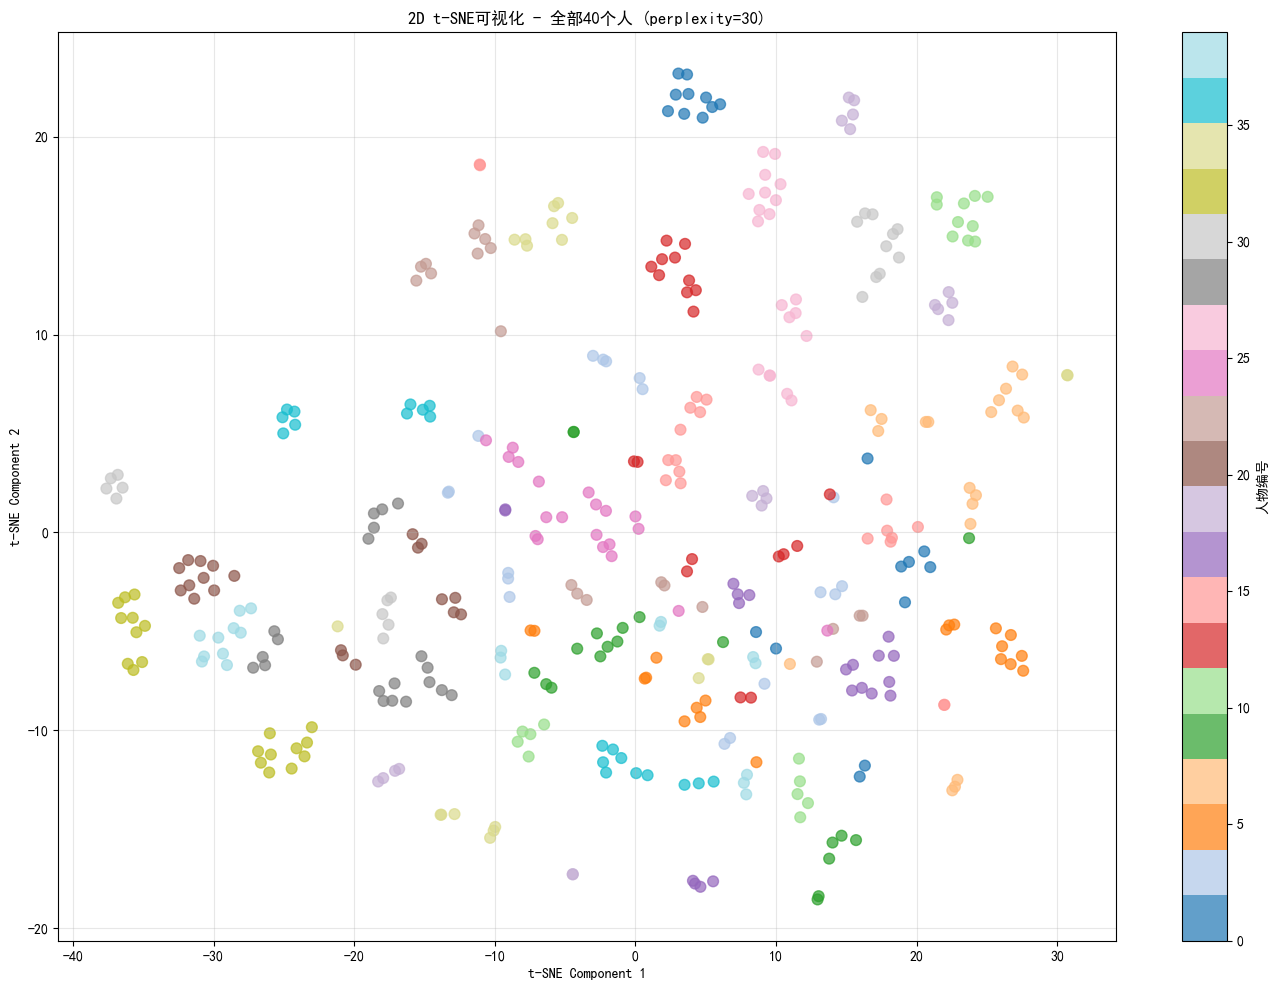

1. 最佳perplexity: 30
2. 最佳聚类准确率: 97.00%
3. t-SNE可视化特点:
   - 2D可视化效果清晰，不同人物形成明显的簇
   - 同一人物的样本在2D空间中高度聚集
   - 不同人物之间存在清晰的边界


In [47]:
#t-SNE
from sklearn.manifold import TSNE

# ============ 3. t-SNE分析（2D和3D） ============
print("\n【t-SNE降维分析】")
# 3.1 2D t-SNE
print("\n执行 2D t-SNE (perplexity=30)")
start_time = time.time()
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42, 
               max_iter=1000, init='pca')
X_tsne_2d = tsne_2d.fit_transform(X_pca)


# 3.2 3D t-SNE
print("\n执行 3D t-SNE (perplexity=30)")
try:
    start_time = time.time()
    tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42,
                   max_iter=1000, init='pca')
    X_tsne_3d = tsne_3d.fit_transform(X_pca)
    has_3d = True
except Exception as e:
    print(f" 3D t-SNE失败: {e}")
    has_3d = False
    X_tsne_3d = None

# 3.3 不同perplexity值对比（仅2D）
print("\n执行不同perplexity的2D t-SNE")
perplexities = [5, 10, 20, 30, 40, 50]
tsne_results = {}

for perp in perplexities:
    print(f"  perplexity={perp}", end="")
    try:
        tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
                    max_iter=500, init='pca')
        X_tsne = tsne.fit_transform(X_pca)
        tsne_results[perp] = X_tsne
        print(f" 完成")
    except Exception as e:
        print(f" 失败: {e}")
        tsne_results[perp] = None

# ============ 4. 可视化 ============

# 4.1 2D t-SNE散点图
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
scatter = plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], 
                      c=y, cmap='tab20', alpha=0.7, s=50)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('2D t-SNE可视化 (perplexity=30)')
plt.colorbar(scatter, label='人物编号')
plt.grid(True, alpha=0.3)

# 4.2 前10个人
plt.subplot(1, 3, 2)
for i in range(10):
    mask = y == i
    plt.scatter(X_tsne_2d[mask, 0], X_tsne_2d[mask, 1], 
               label=f'Person {i}', alpha=0.7, s=30)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('前10个人的2D分布')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.grid(True, alpha=0.3)

# 4.3 与PCA对比
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.subplot(1, 3, 3)
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                      c=y, cmap='tab20', alpha=0.7, s=50)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('2D PCA对比')
plt.colorbar(scatter, label='人物编号')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4.4 3D可视化（如果有）
if has_3d:
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2],
                        c=y, cmap='tab20', alpha=0.7, s=40)
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.set_zlabel('t-SNE Component 3')
    ax.set_title('3D t-SNE可视化 (perplexity=30)')
    plt.colorbar(scatter, label='人物编号')
    plt.tight_layout()
    plt.show()

# ============ 5. 不同perplexity可视化对比 ============
print("\n【不同perplexity可视化对比】")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (perp, X_tsne) in enumerate(tsne_results.items()):
    if X_tsne is not None:
        axes[idx].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                         c=y, cmap='tab20', alpha=0.6, s=15)
        axes[idx].set_title(f'perplexity={perp}')
        axes[idx].set_xlabel('Component 1')
        axes[idx].set_ylabel('Component 2')
        axes[idx].grid(True, alpha=0.3)
    else:
        axes[idx].text(0.5, 0.5, f'perplexity={perp}\n失败', 
                      ha='center', va='center', fontsize=12)
        axes[idx].set_title(f'perplexity={perp}')

plt.tight_layout()
plt.show()

# ============ 6. 不同perplexity下的聚类效果评估 ============
print("\n【不同perplexity聚类效果评估】")

perp_accuracies = []

for perp, X_tsne in tsne_results.items():
    if X_tsne is not None:
        knn = KNeighborsClassifier(n_neighbors=3)
        knn.fit(X_tsne, y)
        acc = accuracy_score(y, knn.predict(X_tsne))
        perp_accuracies.append(acc)
        print(f"  perplexity={perp:2d}: 准确率 = {acc*100:.2f}%")
    else:
        perp_accuracies.append(0)

# 可视化perplexity影响
plt.figure(figsize=(10, 5))
valid_perps = [p for p, acc in zip(perplexities, perp_accuracies) if acc > 0]
valid_accs = [acc for acc in perp_accuracies if acc > 0]

if valid_accs:
    plt.plot(valid_perps, valid_accs, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('perplexity')
    plt.ylabel('聚类准确率')
    plt.title('t-SNE：perplexity对聚类效果的影响')
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 1])

    best_idx = np.argmax(valid_accs)
    best_perp = valid_perps[best_idx]
    best_acc = valid_accs[best_idx]
    plt.annotate(f'最佳: perplexity={best_perp}\n准确率: {best_acc*100:.2f}%',
                 xy=(best_perp, best_acc), xytext=(best_perp+5, best_acc-0.1),
                 arrowprops=dict(arrowstyle='->', lw=1.5, color='red'))

plt.tight_layout()
plt.show()

# ============ 7. t-SNE可视化效果展示 ============
print("\n【t-SNE聚类效果展示】")

# 为了展示t-SNE的聚类能力，使用2D可视化并显示更多人物
plt.figure(figsize=(14, 10))

# 显示所有40个人（用不同颜色）
plt.subplot(1, 1, 1)
scatter = plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], 
                      c=y, cmap='tab20', alpha=0.7, s=60)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title(f'2D t-SNE可视化 - 全部40个人 (perplexity=30)')
plt.colorbar(scatter, label='人物编号', ticks=range(0, 40, 5))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============ 8. 总结 ============
if valid_accs:
    print(f"1. 最佳perplexity: {best_perp}")
    print(f"2. 最佳聚类准确率: {best_acc*100:.2f}%")